In [1]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299,299)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [7]:
model = models.inception_v3(pretrained=True, aux_logits=True)

# Modify main classifier
model.fc = nn.Linear(model.fc.in_features, len(class_names))

# Modify auxiliary classifier
model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, len(class_names))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 206MB/s] 


In [8]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifiers
for param in model.fc.parameters():
    param.requires_grad = True

for param in model.AuxLogits.parameters():
    param.requires_grad = True

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [10]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs, aux_outputs = model(images)
                loss1 = criterion(outputs, labels)
                loss2 = criterion(aux_outputs, labels)
                loss = loss1 + 0.4 * loss2  # important

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_inception.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_inception.pth"))
    return model

In [11]:
for param in model.parameters():
    param.requires_grad = True

In [12]:
model = train_model(model, train_loader, val_loader, epochs=30)

/tmp/ipykernel_101/643962675.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_101/643962675.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30
Train Loss: 0.6693 | Train Acc: 0.7988
Val Loss: 0.3318 | Val Acc: 0.8552 | Val F1: 0.8485
Best F1: 0.8485
--------------------------------------------------


/tmp/ipykernel_101/643962675.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/30
Train Loss: 0.4957 | Train Acc: 0.8504
Val Loss: 0.2984 | Val Acc: 0.8868 | Val F1: 0.8865
Best F1: 0.8865
--------------------------------------------------


/tmp/ipykernel_101/643962675.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 28/30
Train Loss: 0.0054 | Train Acc: 0.9992
Val Loss: 0.2627 | Val Acc: 0.9468 | Val F1: 0.9467
Best F1: 0.9474
--------------------------------------------------


/tmp/ipykernel_101/643962675.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 29/30
Train Loss: 0.0033 | Train Acc: 0.9999
Val Loss: 0.2647 | Val Acc: 0.9480 | Val F1: 0.9479
Best F1: 0.9479
--------------------------------------------------


/tmp/ipykernel_101/643962675.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 30/30
Train Loss: 0.0053 | Train Acc: 0.9992
Val Loss: 0.2660 | Val Acc: 0.9437 | Val F1: 0.9436
Best F1: 0.9479
--------------------------------------------------


In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       405
             Normal       0.99      0.99      0.99       405
Pneumonia-Bacterial       0.92      0.87      0.89       405
    Pneumonia-Viral       0.88      0.91      0.89       405

           accuracy                           0.94      1620
          macro avg       0.94      0.94      0.94      1620
       weighted avg       0.94      0.94      0.94      1620



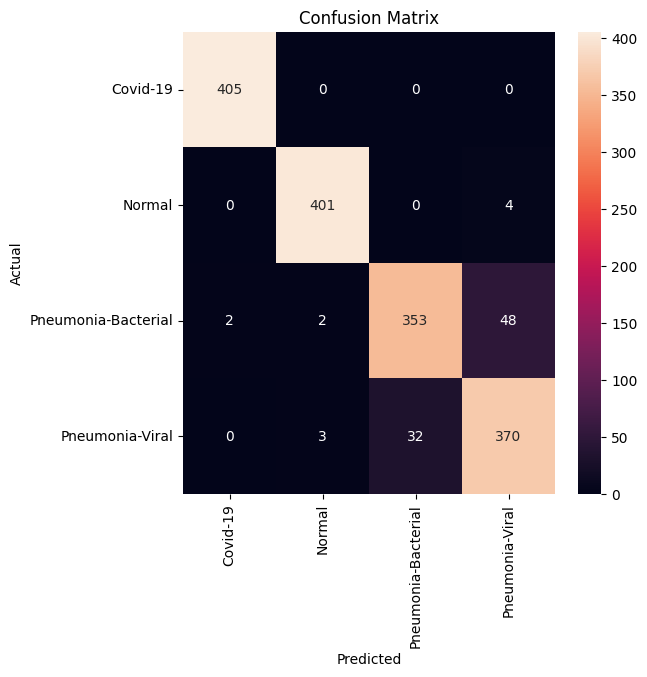

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [16]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

In [17]:
num_classes = all_probs.shape[1]

# Convert labels to one-hot
labels_onehot = label_binarize(all_labels, classes=list(range(num_classes)))

roc_auc = roc_auc_score(labels_onehot, all_probs, average='macro')
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9924333180917543


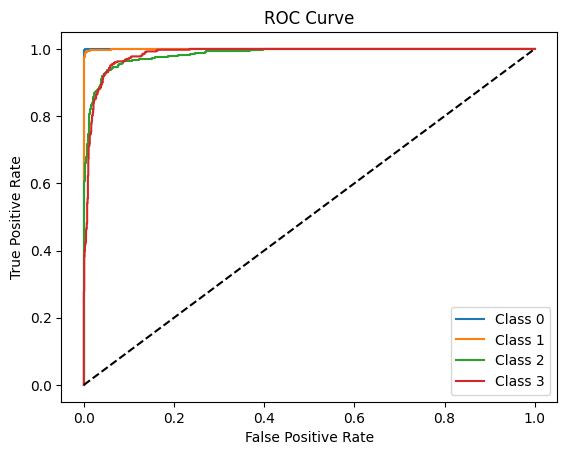

In [18]:
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=[2,3], keepdim=True)
        cam = (weights * activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

In [20]:
target_layer = model.Mixed_7c  # last conv layer
grad_cam = GradCAM(model, target_layer)

In [21]:
images, labels = next(iter(test_loader))
input_img = images[0:1].to(device)

cam = grad_cam.generate(input_img, labels[0].item())

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


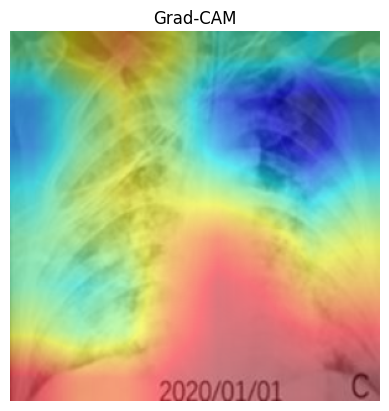

In [22]:
import cv2

img = images[0].permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

heatmap = cv2.applyColorMap(np.uint8(255*cam_resized), cv2.COLORMAP_JET)
overlay = heatmap/255 + img
overlay = overlay / overlay.max()

plt.imshow(overlay)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [23]:
def generate_masks(N, s, p1):
    masks = np.random.rand(N, s, s) < p1
    masks = masks.astype(np.float32)

    masks = torch.tensor(masks)
    masks = torch.nn.functional.interpolate(
        masks.unsqueeze(1),
        size=(299, 299),  # Inception input size
        mode='bilinear'
    )
    return masks

In [24]:
class RISE:
    def __init__(self, model, N=2000, s=8, p1=0.5):
        self.model = model
        self.N = N
        self.s = s
        self.p1 = p1

        self.masks = generate_masks(N, s, p1)

    def explain(self, image, class_idx):
        _, _, H, W = image.shape

        masked = self.masks.to(device) * image

        preds = []
        with torch.no_grad():
            for i in range(0, self.N, 32):
                batch = masked[i:i+32]
                out = torch.softmax(self.model(batch), dim=1)
                preds.append(out[:, class_idx].cpu())

        preds = torch.cat(preds)

        saliency = (preds.view(-1,1,1,1) * self.masks).sum(0)
        saliency = saliency.squeeze().numpy()

        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

        return saliency

In [25]:
rise = RISE(model, N=1000)

In [26]:
saliency = rise.explain(input_img, labels[0].item())

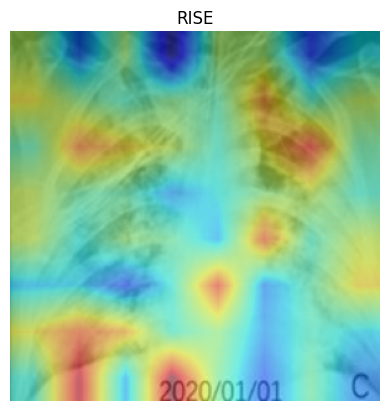

In [27]:
saliency_resized = cv2.resize(saliency, (img.shape[1], img.shape[0]))

plt.imshow(img)
plt.imshow(saliency_resized, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("RISE")
plt.show()